In [1]:
!pip install legacy-cgi opendatasets --quiet
import opendatasets as od

od.download("https://www.kaggle.com/datasets/marquis03/bean-leaf-lesions-classification")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: muntazirmehdi3131
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/marquis03/bean-leaf-lesions-classification


100%|██████████| 155M/155M [00:01<00:00, 122MB/s]


In [2]:
import torch
import torch.nn
from torch.optim import Adam
from torchvision.transforms import transforms
from torch.utils.data import DataLoader , Dataset
from torchvision import models
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from PIL import Image
import os

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print (device)
print(os.listdir("/content"))

cuda
['.config', 'bean-leaf-lesions-classification', 'sample_data']


In [3]:
train_df = pd.read_csv("/content/bean-leaf-lesions-classification/train.csv")
val_df = pd.read_csv("/content/bean-leaf-lesions-classification/val.csv")

train_df["image:FILE"] = "/content/bean-leaf-lesions-classification/" + train_df["image:FILE"]
val_df["image:FILE"] = "/content/bean-leaf-lesions-classification/" + val_df["image:FILE"]

train_df.head()

,image:FILE,category
0,/content/bean-leaf-lesions-classification/trai...,0
1,/content/bean-leaf-lesions-classification/trai...,0
2,/content/bean-leaf-lesions-classification/trai...,0
3,/content/bean-leaf-lesions-classification/trai...,0
4,/content/bean-leaf-lesions-classification/trai...,0


In [4]:
# now we will check how many unique classes we have for our training data
print(train_df['category'].unique())

print(train_df.shape)
print(val_df.shape)

[0 1 2]
(1034, 2)
(133, 2)


In [5]:
print(train_df['category'].value_counts())

category
2    348
1    345
0    341
Name: count, dtype: int64


In [6]:
Transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float)
])

In [7]:
class CustomImageDataset(Dataset):
  def __init__(self,dataframe,transform=None):
    self.dataframe = dataframe
    self.transform = transform
    self.labels = torch.tensor(dataframe['category']).to(device)

  def __len__(self):
    return self.dataframe.shape[0]

  def __getitem__(self,index):
    image_path = self.dataframe.iloc[index,0]
    label = self.labels[index]
    image = Image.open(image_path)
    if self.transform:
      image = (self.transform(image)/255.0).to(device)
    return image , label




In [8]:
train_dataset = CustomImageDataset(train_df,transform= Transform)
val_dataset = CustomImageDataset(val_df ,transform = Transform)

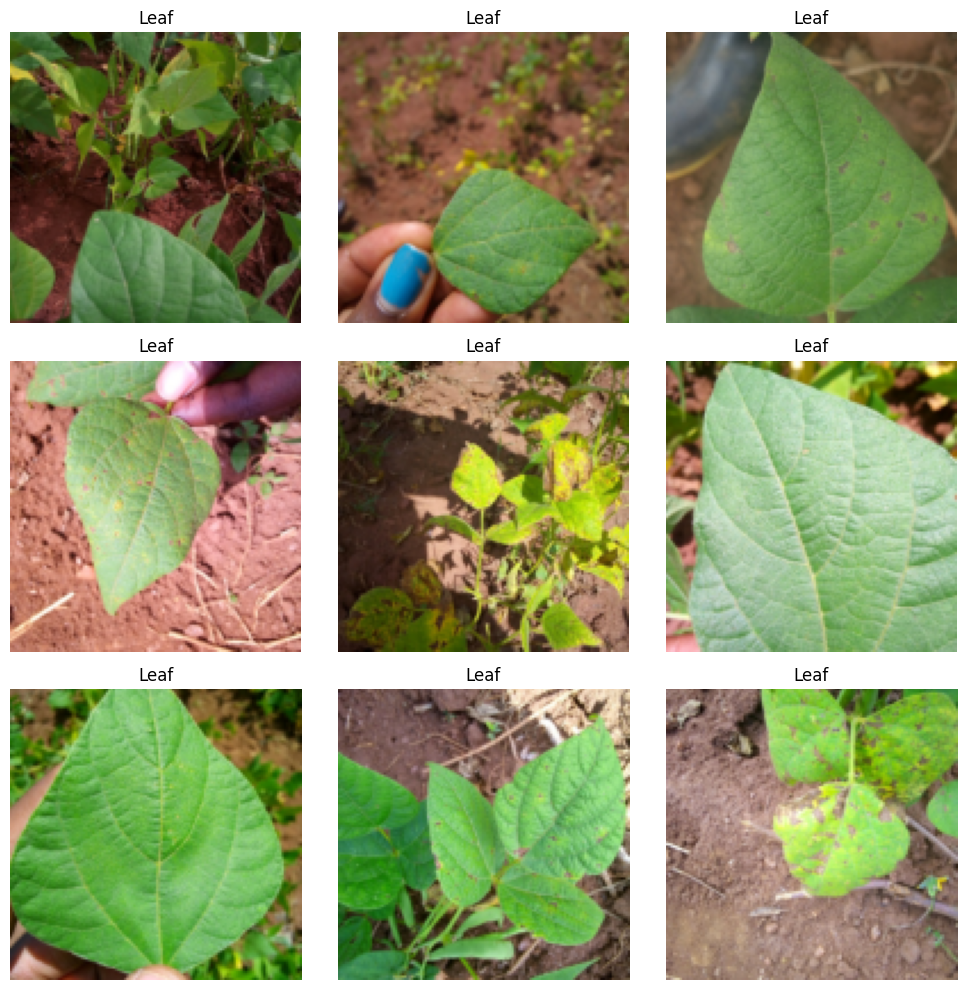

In [9]:
nrows = 3
ncols = 3

fig , axs = plt.subplots(nrows,ncols,figsize=(10,10))

for i in range (nrows):
  for j in range (ncols):
    image = train_dataset[np.random.randint(0,train_dataset.__len__())][0].cpu()
    axs[i,j].imshow((image*255.0).squeeze().permute(1,2,0))
    axs[i,j].set_title("Leaf")
    axs[i,j].axis("off")

plt.tight_layout()
plt.show()


In [10]:
#defining constants
LR = 1e-3
BATCH_SIZE = 4
EPOCH = 15

In [11]:
train_dataloader = DataLoader(train_dataset,batch_size = BATCH_SIZE, shuffle = True )
val_dataloader = DataLoader(val_dataset,batch_size = BATCH_SIZE, shuffle = True )


In [12]:
# Heres the extra part you have to perform for using pretrained model
# There are two methods to do this one is transfer learning and second is train from scratch

In [13]:
# now move the model to device
googlenet_model = models.googlenet(weights='DEFAULT')

for i in googlenet_model.parameters():
  i.requires_grad = True

Downloading: "https://download.pytorch.org/models/googlenet-1378be20.pth" to /root/.cache/torch/hub/checkpoints/googlenet-1378be20.pth


100%|██████████| 49.7M/49.7M [00:00<00:00, 77.4MB/s]


In [14]:
googlenet_model.fc

Linear(in_features=1024, out_features=1000, bias=True)

In [15]:
# now you have to change the out_features to you classes numbers so first find the unique classes count
length = len(train_df['category'].unique())

googlenet_model.fc = torch.nn.Linear(googlenet_model.fc.in_features,length)
# now after converting move it to device
googlenet_model.to(device)

GoogLeNet(
  (conv1): BasicConv2d(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (conv2): BasicConv2d(
    (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv3): BasicConv2d(
    (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (inception3a): Inception(
    (branch1): BasicConv2d(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track

In [16]:
# loss and acc function var
losscal = torch.nn.CrossEntropyLoss()
acc = Adam(googlenet_model.parameters(),lr=LR)

# four arrays for ploting
total_train_loss = []
total_val_loss = []
total_train_acc = []
total_val_acc = []

for epoch in range(EPOCH):
  train_loss =0
  train_acc=0
  val_loss =0
  val_acc=0
  for data in train_dataloader:
    image,label = data
    acc.zero_grad()
    output = googlenet_model(image)
    loss  = losscal(output,label)
    train_loss+= loss.item()
    loss.backward()
    accu = (torch.argmax(output, axis= 1 ) == label).sum().item()
    train_acc+=accu
    acc.step()
  with torch.no_grad():
      for data in val_dataloader:
        image,label = data
        output = googlenet_model(image)
        loss  = losscal(output,label)
        val_loss+= loss.item()
        accu = (torch.argmax(output, axis= 1 ) == label).sum().item()
        val_acc+=accu
  total_train_loss.append(round(train_loss/1000,4))
  total_train_acc.append(round(train_acc/train_dataset.__len__() ,4))
  total_val_loss.append(round(val_loss/1000,4))
  total_val_acc.append(round(val_acc/val_dataset.__len__() ,4))

  print(f"Train loss {round(train_loss/1000,4)} Train acc {round(train_acc/train_dataset.__len__() ,4)} Val loss {round(val_loss/1000,4)} Val acc {round(val_acc/val_dataset.__len__() ,4)}")


Train loss 0.2451 Train acc 0.5658 Val loss 0.0279 Val acc 0.6316
Train loss 0.2197 Train acc 0.6296 Val loss 0.0291 Val acc 0.5789
Train loss 0.2166 Train acc 0.6383 Val loss 0.025 Val acc 0.7444
Train loss 0.2012 Train acc 0.6644 Val loss 0.0288 Val acc 0.6692
Train loss 0.1808 Train acc 0.706 Val loss 0.0233 Val acc 0.7368
Train loss 0.1837 Train acc 0.7021 Val loss 0.0301 Val acc 0.5564
Train loss 0.1589 Train acc 0.7544 Val loss 0.0176 Val acc 0.812
Train loss 0.1433 Train acc 0.793 Val loss 0.0271 Val acc 0.7218
Train loss 0.1401 Train acc 0.7892 Val loss 0.0158 Val acc 0.8346
Train loss 0.1391 Train acc 0.793 Val loss 0.0182 Val acc 0.8421
Train loss 0.137 Train acc 0.8027 Val loss 0.0155 Val acc 0.8271
Train loss 0.1217 Train acc 0.8095 Val loss 0.0133 Val acc 0.8346
Train loss 0.1332 Train acc 0.8162 Val loss 0.0125 Val acc 0.9098
Train loss 0.1073 Train acc 0.8424 Val loss 0.0136 Val acc 0.8496
Train loss 0.1109 Train acc 0.8385 Val loss 0.01 Val acc 0.8947


In [17]:
with torch.no_grad():
  test_loss = 0
  test_acc = 0
  for data in val_dataloader:
    input , label = data
    output = googlenet_model(input)

    loss = losscal(output,label)
    test_loss += loss.item()
    acc = (torch.argmax(output ,axis=1)== label).sum().item()
    test_acc += acc
  print(f"Test loss {round(test_loss/1000,4)} Test acc {round(test_acc/val_dataset.__len__() ,4)}")


Test loss 0.0122 Test acc 0.8571
